In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [33]:
# --- 1. Wireless Environment Parameters ---
B_HZ = 1e6              # 1 MHz
N0_DBM_HZ = -174        # Noise density
P_TX_CLIENT_DBM = 24    # Uplink Power
P_TX_SERVER_DBM = 46    # Downlink Power (Server)
Q_BITS = 16             # 16-bit quantization
RADIUS_KM = 0.5         # 500m
DEVICE_GFLOPS = 2.0     # Average edge device speed (2 Billion operations/sec)

In [19]:
# --- 2. Model Architectures ---

class SVMModel(nn.Module):
    def __init__(self):
        super(SVMModel, self).__init__()
        self.fc = nn.Linear(3072, 1)
    def forward(self, x):
        return self.fc(x.view(x.size(0), -1))

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 5), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 5), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(nn.Linear(64 * 4 * 4, 512), nn.ReLU(), nn.Linear(512, 10))
    def forward(self, x):
        x = self.conv(x)
        return self.fc(x.view(x.size(0), -1))

In [44]:
def get_round_delays(model, task):
    # --- 1. Wireless Environment Setup ---
    # Total Bandwidth B = 1MHz
    B_total = B_HZ 
    K = 30 # Number of devices
    
    # OFDMA Uplink: Each device gets a sub-channel Bk
    Bk = B_total / K 
    
    # Noise calculation (N0 * Bandwidth)
    # For Uplink: Noise power in sub-channel Bk
    noise_w_up = 10**(((N0_DBM_HZ + 10 * np.log10(Bk)) - 30) / 10)
    # For Downlink: Noise power in total bandwidth B
    noise_w_down = 10**(((N0_DBM_HZ + 10 * np.log10(B_total)) - 30) / 10)

    # Path Loss & Distances
    r_km = RADIUS_KM * np.sqrt(np.random.rand(K)) 
    path_loss_db = 128.1 + 37.6 * np.log10(np.maximum(r_km, 0.01))
    
    # Payload Size (N * q)
    num_params = sum(p.numel() for p in model.parameters())
    payload_bits = num_params * Q_BITS

    # --- 2. Downlink Calculation (Equation 5) ---
    # Downlink SNR (gamma) is determined by the device with the worst channel gain
    p_rx_dbm_down = P_TX_SERVER_DBM - path_loss_db
    p_rx_w_down = 10**((p_rx_dbm_down - 30) / 10)
    
    gamma_down = np.min(p_rx_w_down / noise_w_down) # Minimum SNR among devices
    r_downlink = B_total * np.log2(1 + gamma_down)  # Achievable rate r
    d_down = payload_bits / r_downlink

    # --- 3. Uplink Calculation (Equation 4) ---
    # Achievable rate r_k for each device k using sub-channel Bk
    p_rx_dbm_up = P_TX_CLIENT_DBM - path_loss_db
    p_rx_w_up = 10**((p_rx_dbm_up - 30) / 10)
    
    gamma_up = p_rx_w_up / noise_w_up         # SNR gamma_k for each device
    rk_uplink = Bk * np.log2(1 + gamma_up)    # Achievable rate r_k
    
    # Total Uplink delay is the time until the last device k finishes
    d_up = np.max(payload_bits / rk_uplink)

    # --- 4. Computation Delay ---
    flops_per_img = 6000 if task == 'SVM' else 15_000_000
    num_samples = 330 if task == 'SVM' else 2000
    t_comp = (num_samples * flops_per_img) / (DEVICE_GFLOPS * 1e9)

    return d_down, t_comp, d_up

In [35]:
# --- 4. Data Preparation ---

def get_datasets(task='CNN'):
    if task == 'SVM':
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
        train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
        test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
        
        # Filter classes 0 (airplane) and 1 (automobile)
        train_idx = [i for i, l in enumerate(train_set.targets) if l in [0, 1]]
        test_idx = [i for i, l in enumerate(test_set.targets) if l in [0, 1]]
        
        # 15 devices get only airplanes, 15 get only automobiles (330 samples each)
        airplanes = [i for i in train_idx if train_set.targets[i] == 0][:15*330]
        autos = [i for i in train_idx if train_set.targets[i] == 1][:15*330]
        
        device_data = [Subset(train_set, airplanes[i*330:(i+1)*330]) for i in range(15)] + \
                      [Subset(train_set, autos[i*330:(i+1)*330]) for i in range(15)]
        
        return device_data, Subset(test_set, test_idx), SVMModel(), 0.0001

    else: # CNN Task
        transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
        train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
        
        # Pathological Non-IID: Sort by label, 60 shards, 2 per client
        indices = np.argsort(train_set.targets.numpy())
        shards = [indices[i*1000 : (i+1)*1000] for i in range(60)]
        device_data = [Subset(train_set, np.concatenate((shards[i*2], shards[i*2+1]))) for i in range(30)]
        
        return device_data, test_set, CNNModel(), 0.005

In [43]:
# --- 5. Main Training Logic ---

def run_full_wireless_fl(task='CNN', rounds=15):
    device_data, test_set, global_model, lr = get_datasets(task)
    test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)
    
    # Regularization parameter for SVM (lambda)
    lmbda = 0.01 
    
    history = {'acc': [], 'time': []}
    cumulative_time = 0

    print(f"\n--- Simulation: {task} | 30 Clients | {rounds} Rounds ---")

    for r in range(rounds):
        d_down, t_comp, d_up = get_round_delays(global_model, task)
        round_simulated_time = d_down + t_comp + d_up
        cumulative_time += round_simulated_time
        
        local_weights = []
        for i in range(30):
            local_model = type(global_model)()
            local_model.load_state_dict(global_model.state_dict())
            optimizer = optim.SGD(local_model.parameters(), lr=lr)
            loader = DataLoader(device_data[i], batch_size=32, shuffle=True)
            
            local_model.train()
            for data, target in loader:
                optimizer.zero_grad()
                output = local_model(data).squeeze()
                
                if task == 'SVM':
                    # Table I: 0.5 * max(0, 1 - y * wTx) + (lambda/2) * ||w||^2
                    target_svm = (target.float() * 2) - 1  # Map 0,1 to -1,1
                    hinge_loss = torch.mean(torch.clamp(1 - target_svm * output, min=0))
                    l2_reg = sum(p.pow(2).sum() for p in local_model.parameters())
                    loss = 0.5 * hinge_loss + (lmbda / 2.0) * l2_reg
                else:
                    # Table I: 0.5 * ||y - f(x;w)||^2
                    # Convert labels to One-Hot for MSE calculation
                    target_oh = torch.nn.functional.one_hot(target, num_classes=10).float()
                    # 0.5 multiplier matches the table's factor
                    loss = 0.5 * torch.nn.functional.mse_loss(output, target_oh, reduction='mean')
                
                loss.backward()
                optimizer.step()
                
            local_weights.append(local_model.state_dict())
        
        # Aggregation (FedAvg)
        avg_weights = {}
        for key in local_weights[0].keys():
            avg_weights[key] = torch.stack([local_weights[j][key] for j in range(30)], 0).mean(0)
        global_model.load_state_dict(avg_weights)
        
        # Evaluation
        global_model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                output = global_model(data)
                if task == 'SVM':
                    # SVM prediction: sign of the output
                    correct += (torch.sign(output.squeeze()) == (target.float()*2-1)).sum().item()
                else:
                    # CNN prediction: highest probability digit
                    correct += (output.argmax(1) == target).sum().item()
                total += target.size(0)
        
        acc = 100. * correct / total
        history['acc'].append(acc)
        history['time'].append(cumulative_time)
        
        print(f"Round {r+1:02d} | Acc: {acc:.2f}% | Sim Time: {cumulative_time:.2f}s (Round: {round_simulated_time:.4f}s)")

    # --- Plotting ---
    plt.figure(figsize=(10, 5))
    plt.plot(history['time'], history['acc'], 'b-o', markersize=4)
    plt.title(f'Accuracy vs. Training Time ({task}) - Table I Loss')
    plt.xlabel('Training Time (Seconds)')
    plt.ylabel('Test Accuracy (%)')
    plt.grid(True, alpha=0.3)
    plt.show()


--- Simulation: SVM | 30 Clients | 10 Rounds ---
Round 01 | Acc: 61.80% | Sim Time: 0.13s (Round: 0.1261s)
Round 02 | Acc: 64.90% | Sim Time: 0.25s (Round: 0.1262s)
Round 03 | Acc: 66.45% | Sim Time: 0.38s (Round: 0.1271s)
Round 04 | Acc: 68.20% | Sim Time: 0.51s (Round: 0.1265s)
Round 05 | Acc: 68.40% | Sim Time: 0.63s (Round: 0.1253s)
Round 06 | Acc: 68.80% | Sim Time: 0.76s (Round: 0.1277s)
Round 07 | Acc: 69.35% | Sim Time: 0.89s (Round: 0.1278s)
Round 08 | Acc: 69.90% | Sim Time: 1.01s (Round: 0.1272s)
Round 09 | Acc: 70.30% | Sim Time: 1.14s (Round: 0.1264s)
Round 10 | Acc: 70.80% | Sim Time: 1.27s (Round: 0.1276s)


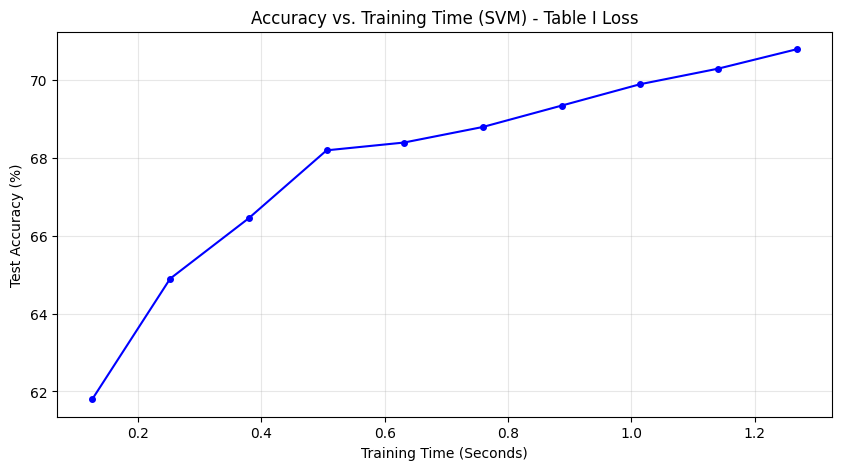

In [46]:
run_full_wireless_fl(task='SVM', rounds=10)


--- Simulation: CNN | 30 Clients | 200 Rounds ---
Round 01 | Acc: 20.63% | Sim Time: 16.93s (Round: 16.9348s)
Round 02 | Acc: 24.08% | Sim Time: 33.89s (Round: 16.9569s)
Round 03 | Acc: 23.92% | Sim Time: 50.84s (Round: 16.9480s)
Round 04 | Acc: 29.45% | Sim Time: 67.79s (Round: 16.9488s)
Round 05 | Acc: 34.73% | Sim Time: 84.71s (Round: 16.9246s)
Round 06 | Acc: 40.45% | Sim Time: 101.67s (Round: 16.9584s)
Round 07 | Acc: 44.02% | Sim Time: 118.58s (Round: 16.9102s)
Round 08 | Acc: 47.31% | Sim Time: 135.54s (Round: 16.9630s)
Round 09 | Acc: 49.44% | Sim Time: 152.49s (Round: 16.9419s)
Round 10 | Acc: 51.18% | Sim Time: 169.44s (Round: 16.9510s)
Round 11 | Acc: 52.54% | Sim Time: 186.38s (Round: 16.9455s)
Round 12 | Acc: 54.14% | Sim Time: 203.32s (Round: 16.9390s)
Round 13 | Acc: 54.89% | Sim Time: 220.28s (Round: 16.9609s)
Round 14 | Acc: 56.84% | Sim Time: 237.25s (Round: 16.9641s)
Round 15 | Acc: 57.74% | Sim Time: 254.17s (Round: 16.9215s)
Round 16 | Acc: 59.71% | Sim Time: 271.

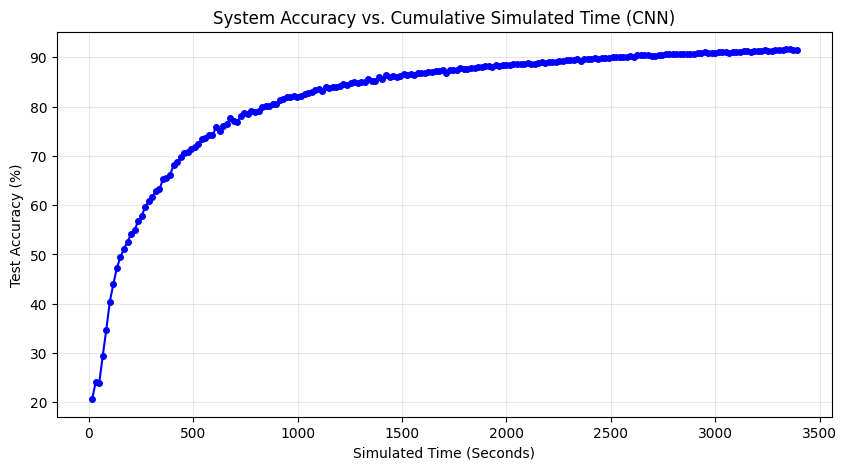

In [40]:
run_full_wireless_fl(task='CNN', rounds=200)